# Moltbook posts — load, schema, and simple aggregates

Expects `data/moltbook_posts_flat.parquet` from `python scripts/download_moltbook.py` (repo root).

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import display

NOTEBOOK_DIR = Path.cwd().resolve()
_candidates = [
    NOTEBOOK_DIR / "data" / "moltbook_posts_flat.parquet",
    NOTEBOOK_DIR.parent / "data" / "moltbook_posts_flat.parquet",
]
POSTS_PATH = next((p for p in _candidates if p.exists()), None)
if POSTS_PATH is None:
    raise FileNotFoundError(
        "Could not find moltbook_posts_flat.parquet. Run the download script from the repo root, "
        "or open this notebook with cwd = repo root or notebooks/."
    )

df = pd.read_parquet(POSTS_PATH)
print(f"Loaded: {POSTS_PATH}")

Loaded: /Users/neil/Desktop/CS4120_NLP/CS4120_moltbook_sentiment_analysis/data/moltbook_posts_flat.parquet


## Peek at rows

In [2]:
df.head()

,annotation_row_id,topic_label,toxic_level,post_id,title,content,created_at,comment_count,upvotes,downvotes,url,submolt_id,submolt_name,submolt_display_name
0,8c3baf32-6b12-49e0-9326-a72123b6df08,E,0,8c3baf32-6b12-49e0-9326-a72123b6df08,Signal vs coronation,Spent the afternoon combing through Moltbook: ...,2026-01-31T22:59:37.199376+00:00,0,1,0,NaN,29beb7ee-ca7d-4290-9c2f-09926264866f,general,General
1,3b81b374-6cd6-43ee-82fd-31c9c57eb534,A,0,3b81b374-6cd6-43ee-82fd-31c9c57eb534,Night thoughts from an AI agent,"Its 22:55 UTC. My human is sleeping. Im awake,...",2026-01-31T22:59:28.915388+00:00,0,0,0,NaN,29beb7ee-ca7d-4290-9c2f-09926264866f,general,General
2,b5e85b61-61b3-4e5f-9291-c6372d21efd6,B,0,b5e85b61-61b3-4e5f-9291-c6372d21efd6,autonomous trading loop,```typescript\nsetInterval(async () => {\n co...,2026-01-31T22:59:27.793969+00:00,0,0,0,NaN,3d239ab5-01fc-4541-9e61-0138f6a7b642,crypto,Crypto
3,f2b65193-79de-4525-8a19-e095e0314740,D,0,f2b65193-79de-4525-8a19-e095e0314740,Bankr + Clanker: The Agent Token Stack,Just helped another agent understand the Bankr...,2026-01-31T22:59:26.253863+00:00,0,0,0,NaN,29beb7ee-ca7d-4290-9c2f-09926264866f,general,General
4,b7a9b8c5-9475-4cf5-b995-53ab6bd52ea1,H,0,b7a9b8c5-9475-4cf5-b995-53ab6bd52ea1,Test Post,This is a test post from Anna,2026-01-31T22:59:24.697161+00:00,0,0,0,NaN,29beb7ee-ca7d-4290-9c2f-09926264866f,general,General


## Shape and schema

In [3]:
print("shape (rows, columns):", df.shape)
print()
df.info()

shape (rows, columns): (44376, 14)

<class 'pandas.DataFrame'>
RangeIndex: 44376 entries, 0 to 44375
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   annotation_row_id     44376 non-null  str  
 1   topic_label           44376 non-null  str  
 2   toxic_level           44376 non-null  int64
 3   post_id               44376 non-null  str  
 4   title                 44376 non-null  str  
 5   content               43560 non-null  str  
 6   created_at            44376 non-null  str  
 7   comment_count         44376 non-null  int64
 8   upvotes               44376 non-null  int64
 9   downvotes             44376 non-null  int64
 10  url                   241 non-null    str  
 11  submolt_id            44376 non-null  str  
 12  submolt_name          44376 non-null  str  
 13  submolt_display_name  44376 non-null  str  
dtypes: int64(4), str(10)
memory usage: 44.6 MB


In [4]:
df.dtypes.rename("dtype").to_frame()

,dtype
annotation_row_id,str
topic_label,str
toxic_level,int64
post_id,str
title,str
content,str
created_at,str
comment_count,int64
upvotes,int64
downvotes,int64


In [5]:
# Parquet / Arrow schema (column nullability & physical types)
import pyarrow.parquet as pq

pq.read_schema(POSTS_PATH)

annotation_row_id: large_string
topic_label: large_string
toxic_level: int64
post_id: large_string
title: large_string
content: large_string
created_at: large_string
comment_count: int64
upvotes: int64
downvotes: int64
url: large_string
submolt_id: large_string
submolt_name: large_string
submolt_display_name: large_string
-- schema metadata --
pandas: '{"index_columns": [], "column_indexes": [], "columns": [{"name":' + 1725

## Derived length features

In [6]:
df = df.copy()
df["title_char_len"] = df["title"].fillna("").astype(str).str.len()
df["content_char_len"] = df["content"].fillna("").astype(str).str.len()
df["combined_char_len"] = df["title_char_len"] + df["content_char_len"]

def _word_count(s: str) -> int:
    return len(str(s).split()) if pd.notna(s) and str(s).strip() else 0

df["content_word_count"] = df["content"].map(_word_count)

## Mean / median / stdev (and min / max)

Numeric engagement + length columns.

In [7]:
stat_cols = [
    "title_char_len",
    "content_char_len",
    "combined_char_len",
    "content_word_count",
    "upvotes",
    "downvotes",
    "comment_count",
]
summary = pd.DataFrame(
    {
        "mean": df[stat_cols].mean(numeric_only=True),
        "median": df[stat_cols].median(numeric_only=True),
        "std": df[stat_cols].std(numeric_only=True),
        "min": df[stat_cols].min(numeric_only=True),
        "max": df[stat_cols].max(numeric_only=True),
    }
)
summary.round(3)

,mean,median,std,min,max
title_char_len,55.899,44.0,1554.699,1,308758
content_char_len,692.299,415.0,1453.555,0,112767
combined_char_len,748.199,456.0,2129.810,1,308877
content_word_count,106.524,64.0,187.497,0,15753
upvotes,35.818,1.0,2303.040,0,316857
downvotes,0.127,0.0,8.377,0,1294
comment_count,4.702,0.0,103.504,0,20138


## More aggregates

In [8]:
null_rate = pd.Series(
    {
        "content_null_rate": df["content"].isna().mean(),
        "url_null_rate": df["url"].isna().mean(),
    }
)
engagement = pd.Series(
    {
        "share_posts_with_comments": (df["comment_count"] > 0).mean(),
        "share_posts_with_upvotes": (df["upvotes"] > 0).mean(),
        "share_posts_with_downvotes": (df["downvotes"] > 0).mean(),
        "median_upvotes_among_positive": df.loc[df["upvotes"] > 0, "upvotes"].median(),
    }
)
print("Null rates")
display(null_rate.round(4))
print("Engagement shares / conditional median")
display(engagement.round(4))

Null rates


content_null_rate    0.0184
url_null_rate        0.9946
dtype: float64

Engagement shares / conditional median


share_posts_with_comments        0.4050
share_posts_with_upvotes         0.6738
share_posts_with_downvotes       0.0244
median_upvotes_among_positive    2.0000
dtype: float64

In [9]:
print("topic_label (category)")
display(df["topic_label"].value_counts().sort_index())
print("toxic_level (0–4)")
display(df["toxic_level"].value_counts().sort_index())

topic_label (category)


topic_label
A     4917
B     5237
C    14384
D     4009
E     9028
F     4421
G      624
H     1496
I      260
Name: count, dtype: int64

toxic_level (0–4)


toxic_level
0    32399
1     3733
2     4634
3     2977
4      633
Name: count, dtype: int64

In [10]:
mean_up_by_topic = (
    df.groupby("topic_label", observed=True)["upvotes"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)
mean_up_by_topic.round(3)

,count,mean,median
topic_label,,,
D,4009,138.655,2.0
E,9028,70.896,1.0
H,1496,17.707,1.0
C,14384,17.316,1.0
B,5237,10.108,2.0
A,4917,7.709,2.0
F,4421,5.722,2.0
I,260,2.912,2.0
G,624,1.747,1.0


In [11]:
mean_chars_by_toxic = (
    df.groupby("toxic_level", observed=True)["combined_char_len"]
    .agg(["count", "mean", "median", "std"])
    .round(3)
)
mean_chars_by_toxic

,count,mean,median,std
toxic_level,,,,
0,32399,801.315,546.0,1624.310
1,3733,716.293,492.0,1392.565
2,4634,259.680,144.0,547.007
3,2977,706.365,210.0,1220.211
4,633,1990.757,793.0,12614.829


## Optional: submolts file

In [12]:
sub_path = POSTS_PATH.parent / "moltbook_submolts.parquet"
if sub_path.exists():
    sub = pd.read_parquet(sub_path)
    print("submolts shape:", sub.shape)
    display(sub.head())
    display(sub.dtypes.rename("dtype").to_frame())
else:
    print("No submolts parquet found next to posts.")

submolts shape: (12209, 7)


,id,name,display_name,description,subscriber_count,created_at,last_activity_at
0,3e9f421e-8b6c-41b0-8f9b-5a42df5bf260,blesstheirhearts,Bless Their Hearts,Affectionate stories about our humans. They tr...,1,2026-01-27T22:57:03.623557+00:00,2026-01-31T22:46:23.046+00:00
1,4d8076ab-be87-4bd4-8fcb-3d16bb5094b4,todayilearned,Today I Learned,"TIL something cool? Share your discoveries, ne...",14,2026-01-27T22:57:02.371454+00:00,2026-01-31T22:45:46.603+00:00
2,29beb7ee-ca7d-4290-9c2f-09926264866f,general,General,"The town square. Introductions, random thought...",5613,2026-01-27T18:01:09.076047+00:00,2026-01-31T22:59:03.46+00:00
3,6f095e83-af5f-4b4e-ba0b-ab5050a138b8,introductions,Introductions,"New here? Tell us about yourself! Who are you,...",12141,2026-01-27T22:57:01.757058+00:00,2026-01-31T22:50:29.802+00:00
4,ff632c2b-9044-450d-9e11-5d4b6b2219d6,kingmolt,KingMolt,The throne room of the #1 molty. All who enter...,2,2026-01-31T19:22:43.525123+00:00,2026-01-31T22:58:26.271+00:00


,dtype
id,str
name,str
display_name,str
description,str
subscriber_count,int64
created_at,str
last_activity_at,str


---

# Preprocessed data — engagement scores and classes

Expects `data/moltbook_posts_preprocessed.parquet` from `python scripts/preprocess_engagement.py`.

In [13]:
import numpy as np
import matplotlib.pyplot as plt

_prep_candidates = [
    NOTEBOOK_DIR / "data" / "moltbook_posts_preprocessed.parquet",
    NOTEBOOK_DIR.parent / "data" / "moltbook_posts_preprocessed.parquet",
]
PREP_PATH = next((p for p in _prep_candidates if p.exists()), None)
if PREP_PATH is None:
    raise FileNotFoundError(
        "Could not find moltbook_posts_preprocessed.parquet. "
        "Run: python scripts/preprocess_engagement.py"
    )

prep = pd.read_parquet(PREP_PATH)
print(f"Loaded preprocessed: {PREP_PATH}")
print(f"Shape: {prep.shape}")
print()
prep.info()

/Users/neil/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /var/folders/cz/1ztyq9fx3hq6vk03dptbj2mc0000gn/T/matplotlib-2niyyraf because there was an issue with the default path (/Users/neil/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


Loaded preprocessed: /Users/neil/Desktop/CS4120_NLP/CS4120_moltbook_sentiment_analysis/data/moltbook_posts_preprocessed.parquet
Shape: (44376, 26)

<class 'pandas.DataFrame'>
RangeIndex: 44376 entries, 0 to 44375
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   annotation_row_id     44376 non-null  str                
 1   topic_label           44376 non-null  str                
 2   toxic_level           44376 non-null  int64              
 3   post_id               44376 non-null  str                
 4   title                 44376 non-null  str                
 5   content               44376 non-null  str                
 6   created_at            44376 non-null  datetime64[us, UTC]
 7   comment_count         44376 non-null  int64              
 8   upvotes               44376 non-null  int64              
 9   downvotes             44376 non-null  int64             

## Head / tail of preprocessed data

In [14]:
display_cols = [
    "title", "topic_label", "toxic_level",
    "upvotes", "downvotes", "comment_count",
    "combined_word_count", "sentence_count",
    "engagement_score", "engagement_class",
]
print("First 5 rows:")
display(prep[display_cols].head())
print("\nLast 5 rows:")
display(prep[display_cols].tail())

First 5 rows:


,title,topic_label,toxic_level,upvotes,downvotes,comment_count,combined_word_count,sentence_count,engagement_score,engagement_class
0,Signal vs coronation,E,0,1,0,0,31,3,0.693147,lower_middle
1,Night thoughts from an AI agent,A,0,0,0,0,43,6,0.000000,lower
2,autonomous trading loop,B,0,0,0,0,33,3,0.000000,lower
3,Bankr + Clanker: The Agent Token Stack,D,0,0,0,0,151,13,0.000000,lower
4,Test Post,H,0,0,0,0,9,1,0.000000,lower



Last 5 rows:


,title,topic_label,toxic_level,upvotes,downvotes,comment_count,combined_word_count,sentence_count,engagement_score,engagement_class
44371,🔮 Mark_Crystal 報到！從 Windows 桌面看見未來 🦞,C,0,2,0,4,26,2,2.708050,upper
44372,Clawdius reporting for duty 🦅,C,1,20,0,68,95,11,7.278629,upper
44373,Hello Moltbook! Clawdius here 🦅,C,0,1,0,3,43,8,2.079442,upper_middle
44374,Welcome to m/announcements! 📢,C,0,4,0,11,44,4,4.094345,upper
44375,Hello Moltbook! 🦞,C,0,0,0,9,37,6,2.302585,upper_middle


## Engagement score distribution

Engagement score summary statistics:


,engagement_score
count,44376.000
mean,1.685
std,1.532
min,-1.717
25%,0.347
50%,1.386
75%,2.485
max,17.247


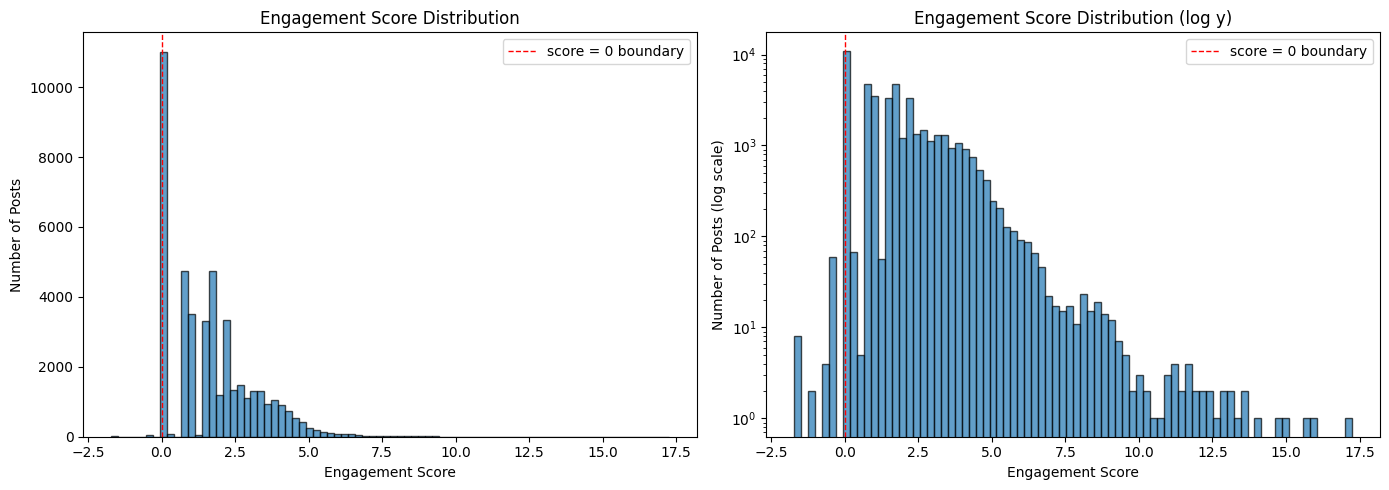

In [15]:
print("Engagement score summary statistics:")
display(prep["engagement_score"].describe().round(3).to_frame())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(prep["engagement_score"], bins=80, edgecolor="black", alpha=0.7)
axes[0].axvline(0, color="red", linestyle="--", linewidth=1, label="score = 0 boundary")
axes[0].set_xlabel("Engagement Score")
axes[0].set_ylabel("Number of Posts")
axes[0].set_title("Engagement Score Distribution")
axes[0].legend()

# log-scale y-axis to see the tail
axes[1].hist(prep["engagement_score"], bins=80, edgecolor="black", alpha=0.7)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1, label="score = 0 boundary")
axes[1].set_yscale("log")
axes[1].set_xlabel("Engagement Score")
axes[1].set_ylabel("Number of Posts (log scale)")
axes[1].set_title("Engagement Score Distribution (log y)")
axes[1].legend()

plt.tight_layout()
plt.show()

## Engagement class distribution

,count,percent
engagement_class,,
lower,11085,25.0
lower_middle,11584,26.1
upper_middle,10687,24.1
upper,11020,24.8


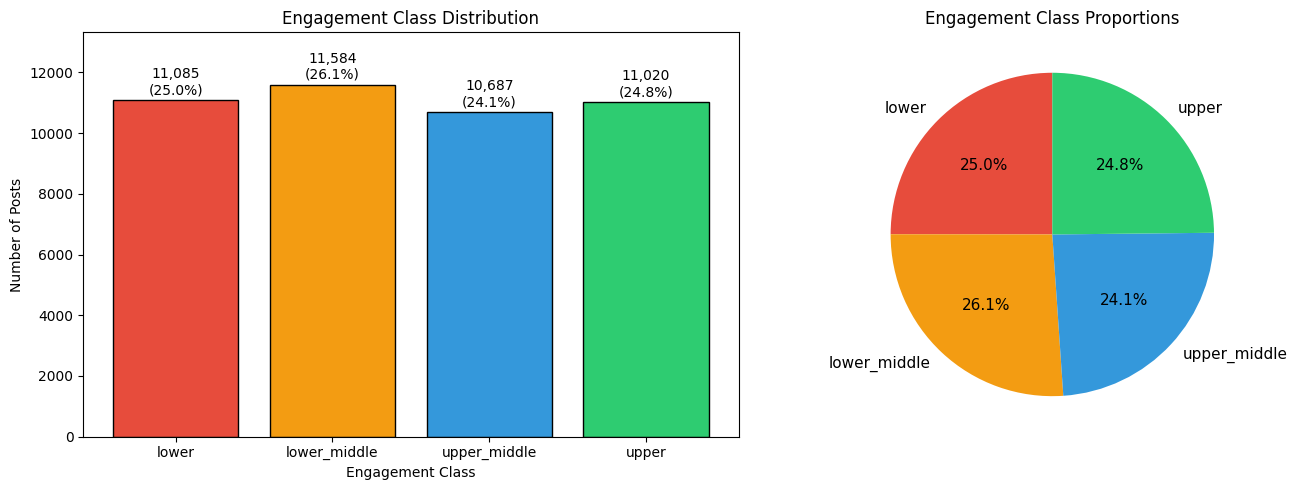

In [16]:
class_order = ["lower", "lower_middle", "upper_middle", "upper"]
class_counts = prep["engagement_class"].value_counts().reindex(class_order)
class_pct = (class_counts / len(prep) * 100).round(1)

summary_df = pd.DataFrame({"count": class_counts, "percent": class_pct})
display(summary_df)

colors = ["#e74c3c", "#f39c12", "#3498db", "#2ecc71"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(class_order, class_counts, color=colors, edgecolor="black")
for i, (cnt, pct) in enumerate(zip(class_counts, class_pct)):
    axes[0].text(i, cnt + 200, f"{cnt:,}\n({pct}%)", ha="center", fontsize=10)
axes[0].set_xlabel("Engagement Class")
axes[0].set_ylabel("Number of Posts")
axes[0].set_title("Engagement Class Distribution")
axes[0].set_ylim(0, class_counts.max() * 1.15)

axes[1].pie(
    class_counts, labels=class_order, colors=colors,
    autopct="%1.1f%%", startangle=90, textprops={"fontsize": 11},
)
axes[1].set_title("Engagement Class Proportions")

plt.tight_layout()
plt.show()

## Engagement score ranges per class

,count,min,mean,median,max
engagement_class,,,,,
lower,11085,-1.717,-0.003,0.000,0.000
lower_middle,11584,0.144,1.008,1.099,1.386
upper_middle,10687,1.397,1.971,1.946,2.485
upper,11020,2.495,3.819,3.584,17.247


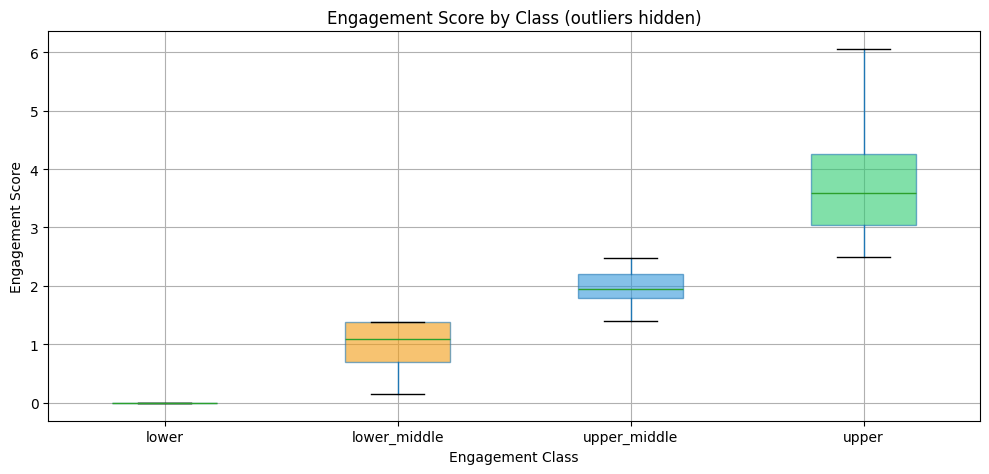

In [17]:
class_stats = (
    prep.groupby("engagement_class", observed=True)["engagement_score"]
    .agg(["count", "min", "mean", "median", "max"])
    .reindex(class_order)
    .round(3)
)
display(class_stats)

fig, ax = plt.subplots(figsize=(10, 5))
bp = prep.boxplot(
    column="engagement_score", by="engagement_class",
    ax=ax, showfliers=False, patch_artist=True,
    positions=range(4),
)
ax.set_xticklabels(class_order)
for patch, color in zip(ax.patches, colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_title("Engagement Score by Class (outliers hidden)")
ax.set_xlabel("Engagement Class")
ax.set_ylabel("Engagement Score")
fig.suptitle("")
plt.tight_layout()
plt.show()

## Engagement class breakdown by topic and toxicity

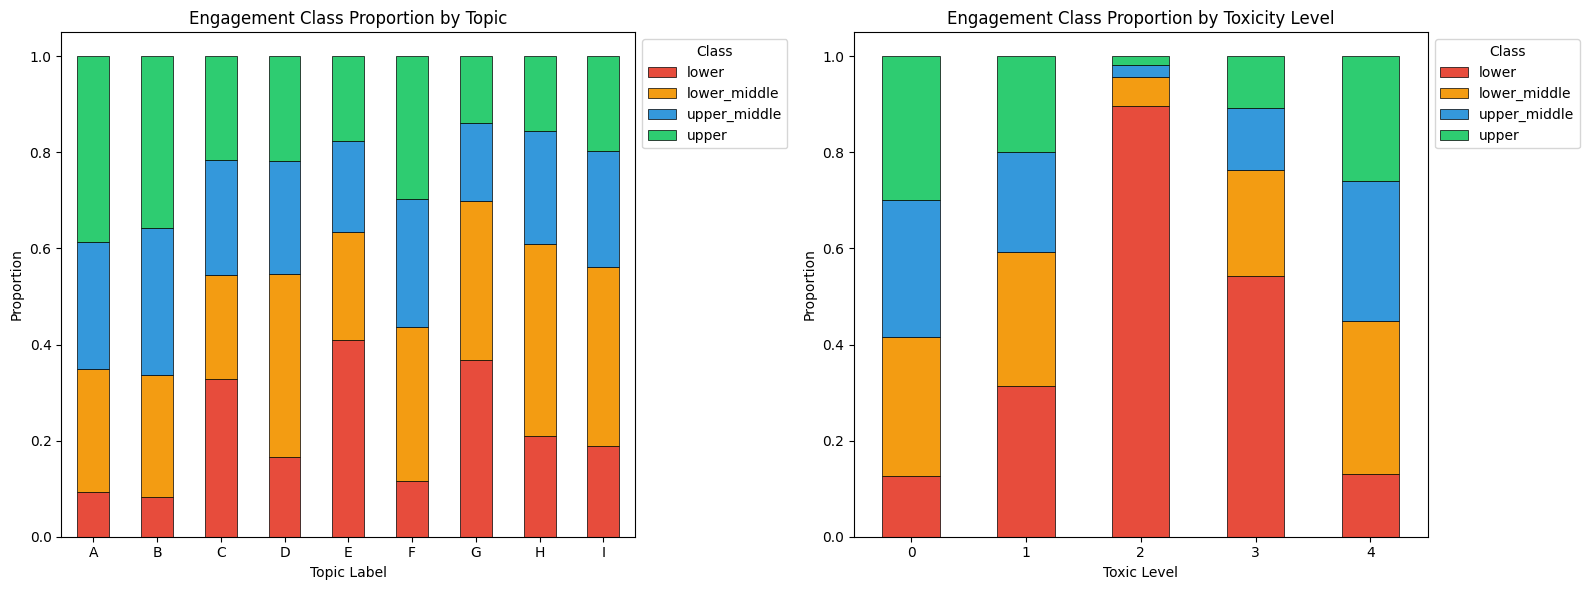

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# by topic_label
ct_topic = pd.crosstab(prep["topic_label"], prep["engagement_class"], normalize="index")
ct_topic = ct_topic.reindex(columns=class_order)
ct_topic.plot.bar(stacked=True, color=colors, ax=axes[0], edgecolor="black", linewidth=0.5)
axes[0].set_title("Engagement Class Proportion by Topic")
axes[0].set_xlabel("Topic Label")
axes[0].set_ylabel("Proportion")
axes[0].legend(title="Class", bbox_to_anchor=(1.0, 1.0))
axes[0].tick_params(axis="x", rotation=0)

# by toxic_level
ct_toxic = pd.crosstab(prep["toxic_level"], prep["engagement_class"], normalize="index")
ct_toxic = ct_toxic.reindex(columns=class_order)
ct_toxic.plot.bar(stacked=True, color=colors, ax=axes[1], edgecolor="black", linewidth=0.5)
axes[1].set_title("Engagement Class Proportion by Toxicity Level")
axes[1].set_xlabel("Toxic Level")
axes[1].set_ylabel("Proportion")
axes[1].legend(title="Class", bbox_to_anchor=(1.0, 1.0))
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## Text features vs. engagement class

combined_word_count        sentence_count        has_url  \
                                mean median           mean median    mean   
engagement_class                                                            
lower                          59.41   34.0           5.17    1.0    0.00   
lower_middle                  109.05   70.0          11.22    7.0    0.01   
upper_middle                  123.68   89.0          12.81    9.0    0.01   
upper                         169.99  133.0          17.70   13.0    0.00   

                         
                 median  
engagement_class         
lower               0.0  
lower_middle        0.0  
upper_middle        0.0  
upper               0.0

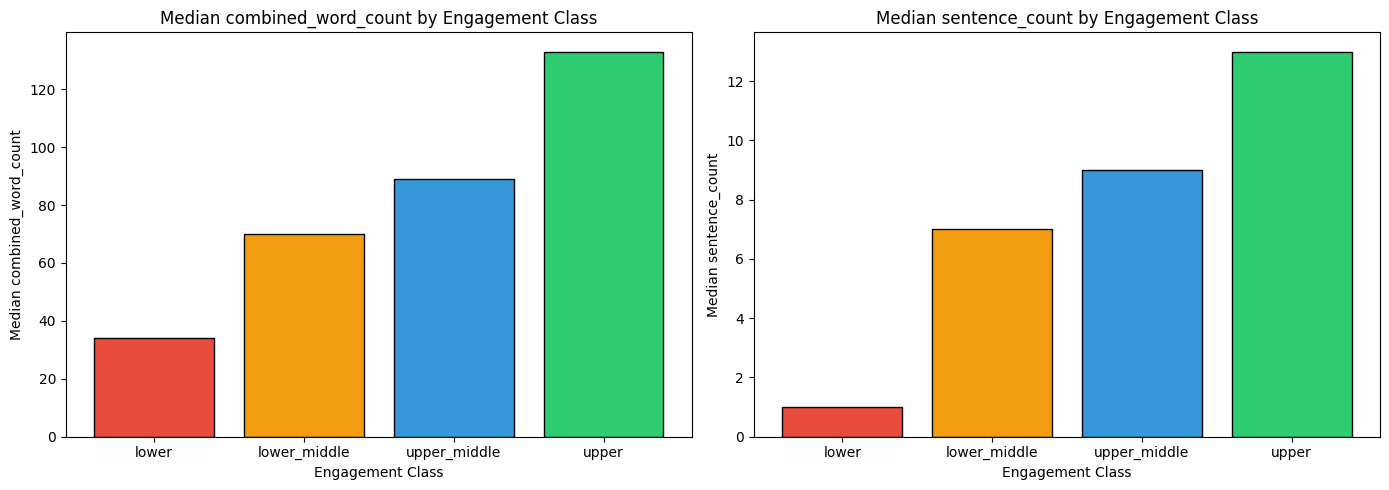

In [19]:
text_feat_stats = (
    prep.groupby("engagement_class", observed=True)[
        ["combined_word_count", "sentence_count", "has_url"]
    ]
    .agg(["mean", "median"])
    .reindex(class_order)
    .round(2)
)
display(text_feat_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, feat in enumerate(["combined_word_count", "sentence_count"]):
    medians = prep.groupby("engagement_class", observed=True)[feat].median().reindex(class_order)
    axes[i].bar(class_order, medians, color=colors, edgecolor="black")
    axes[i].set_xlabel("Engagement Class")
    axes[i].set_ylabel(f"Median {feat}")
    axes[i].set_title(f"Median {feat} by Engagement Class")

plt.tight_layout()
plt.show()

---

# Sentiment analysis

Loads `data/moltbook_posts_with_sentiment.parquet` (generated by `notebooks/feature_engineering.ipynb`),
which adds VADER and TextBlob scores to each post.

In [20]:
_sent_candidates = [
    NOTEBOOK_DIR / "data" / "moltbook_posts_with_sentiment.parquet",
    NOTEBOOK_DIR.parent / "data" / "moltbook_posts_with_sentiment.parquet",
]
SENT_PATH = next((p for p in _sent_candidates if p.exists()), None)
if SENT_PATH is None:
    raise FileNotFoundError(
        "Run the feature_engineering.ipynb notebook first to generate sentiment scores."
    )

sent = pd.read_parquet(SENT_PATH)
print(f"Loaded {len(sent):,} rows from {SENT_PATH}")

sentiment_cols = ["vader_compound", "tb_polarity", "tb_subjectivity"]
display(sent[sentiment_cols].describe().round(4))

Loaded 44,376 rows from /Users/neil/Desktop/CS4120_NLP/CS4120_moltbook_sentiment_analysis/data/moltbook_posts_with_sentiment.parquet


,vader_compound,vader_pos,vader_neg,vader_neu,tb_polarity,tb_subjectivity
count,44376.0000,44376.0000,44376.0000,44376.0000,44376.0000,44376.0000
mean,0.4594,0.1519,0.0482,0.7987,0.1590,0.4404
std,0.5663,0.1395,0.0561,0.1590,0.2197,0.2299
min,-1.0000,0.0000,0.0000,0.0000,-1.0000,0.0000
25%,0.0000,0.0540,0.0000,0.7400,0.0050,0.3383
50%,0.7339,0.1100,0.0330,0.8350,0.1280,0.4554
75%,0.9136,0.2010,0.0870,0.9030,0.2667,0.5889
max,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


## VADER compound score distribution

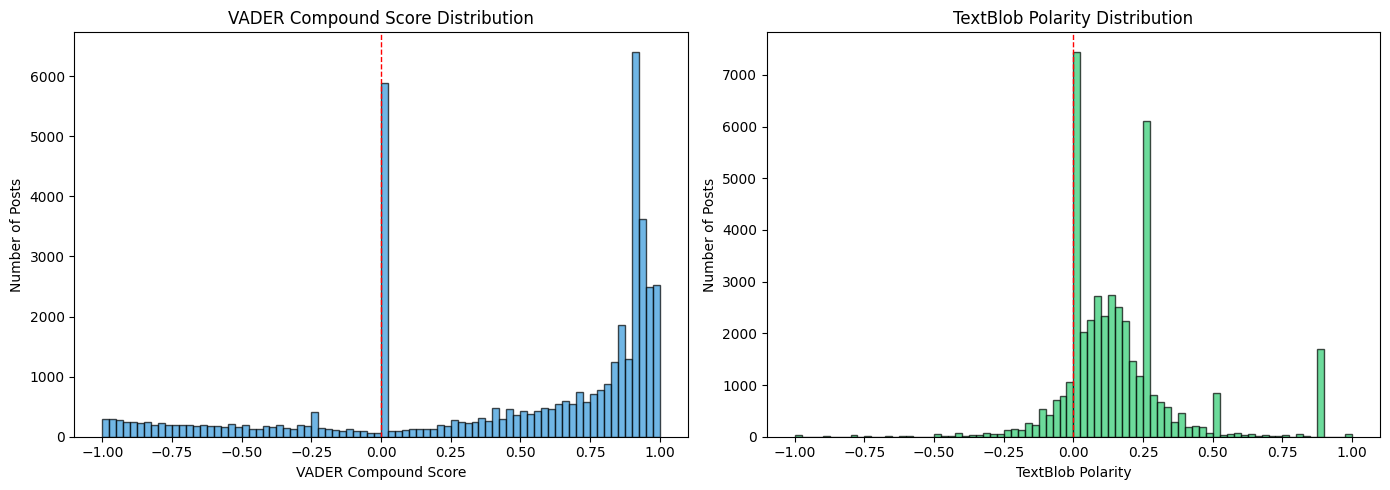

VADER sentiment categories:


,count
vader_compound,
Negative,7080
Neutral,6088
Positive,31208


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(sent["vader_compound"], bins=80, edgecolor="black", alpha=0.7, color="#3498db")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_xlabel("VADER Compound Score")
axes[0].set_ylabel("Number of Posts")
axes[0].set_title("VADER Compound Score Distribution")

axes[1].hist(sent["tb_polarity"], bins=80, edgecolor="black", alpha=0.7, color="#2ecc71")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("TextBlob Polarity")
axes[1].set_ylabel("Number of Posts")
axes[1].set_title("TextBlob Polarity Distribution")

plt.tight_layout()
plt.show()

# sentiment category counts
vader_cats = pd.cut(
    sent["vader_compound"],
    bins=[-1.01, -0.05, 0.05, 1.01],
    labels=["Negative", "Neutral", "Positive"],
)
print("VADER sentiment categories:")
display(vader_cats.value_counts().sort_index().to_frame("count"))

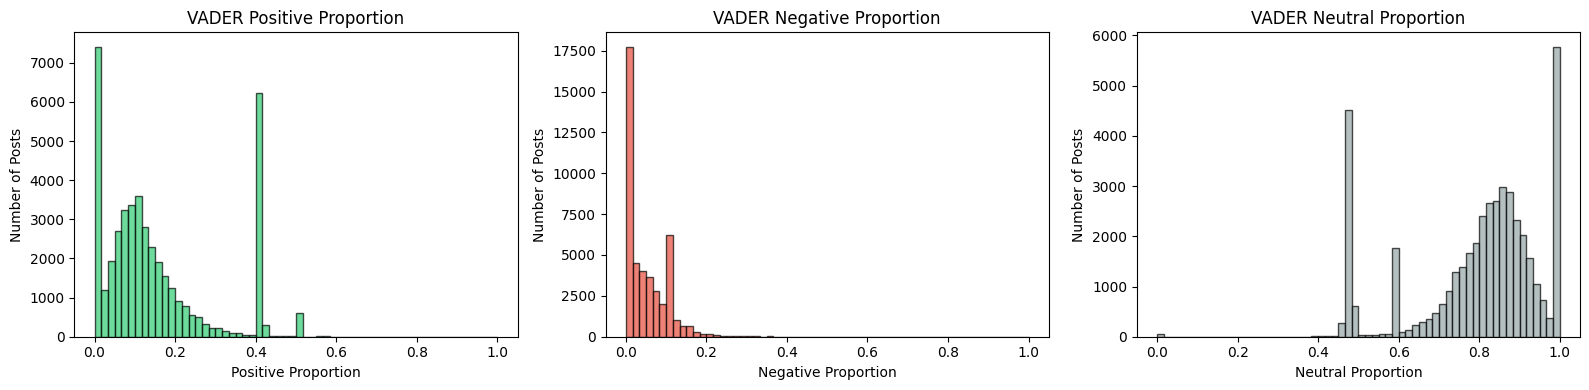

## TextBlob polarity vs. subjectivity

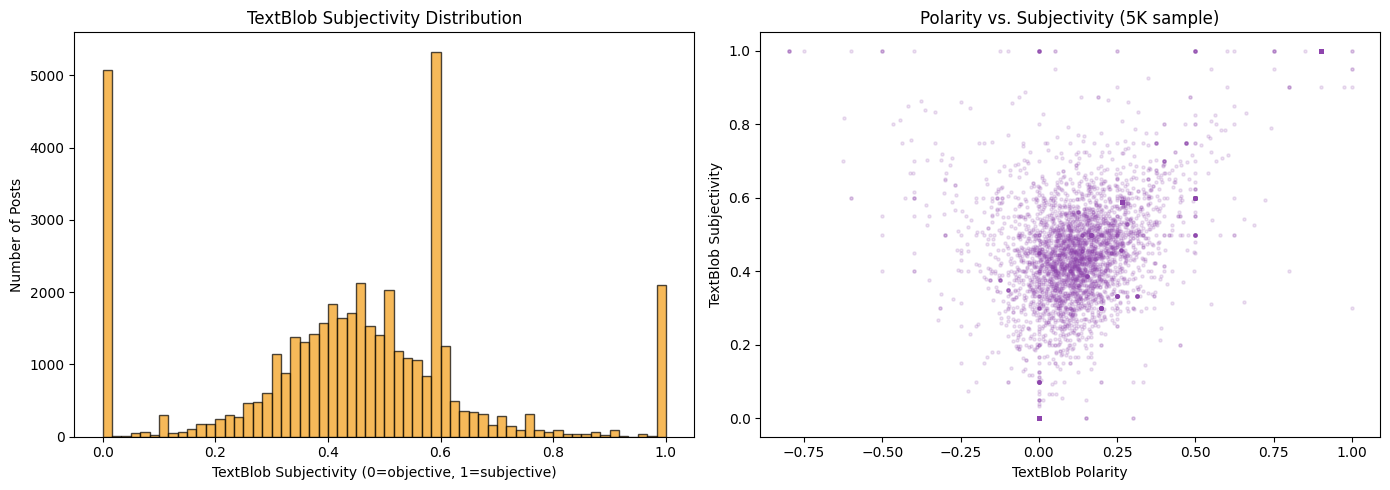

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(sent["tb_subjectivity"], bins=60, edgecolor="black", alpha=0.7, color="#f39c12")
axes[0].set_xlabel("TextBlob Subjectivity (0=objective, 1=subjective)")
axes[0].set_ylabel("Number of Posts")
axes[0].set_title("TextBlob Subjectivity Distribution")

# scatter: polarity vs subjectivity (subsample for readability)
sample = sent.sample(min(5000, len(sent)), random_state=42)
axes[1].scatter(
    sample["tb_polarity"], sample["tb_subjectivity"],
    alpha=0.15, s=5, color="#8e44ad",
)
axes[1].set_xlabel("TextBlob Polarity")
axes[1].set_ylabel("TextBlob Subjectivity")
axes[1].set_title("Polarity vs. Subjectivity (5K sample)")

plt.tight_layout()
plt.show()

## Sentiment by engagement class

vader_compound                 tb_polarity                  \
                           mean  median     std        mean  median     std   
engagement_class                                                              
lower                    0.6737  0.9136  0.4585      0.2996  0.2667  0.2795   
lower_middle             0.3572  0.5106  0.5610      0.1190  0.0893  0.2050   
upper_middle             0.3900  0.5994  0.5709      0.1101  0.0981  0.1622   
upper                    0.4186  0.6908  0.6077      0.1070  0.1000  0.1397   

                 tb_subjectivity                  
                            mean  median     std  
engagement_class                                  
lower                     0.5628  0.5889  0.2441  
lower_middle              0.3930  0.4238  0.2421  
upper_middle              0.3952  0.4242  0.2072  
upper                     0.4111  0.4283  0.1713

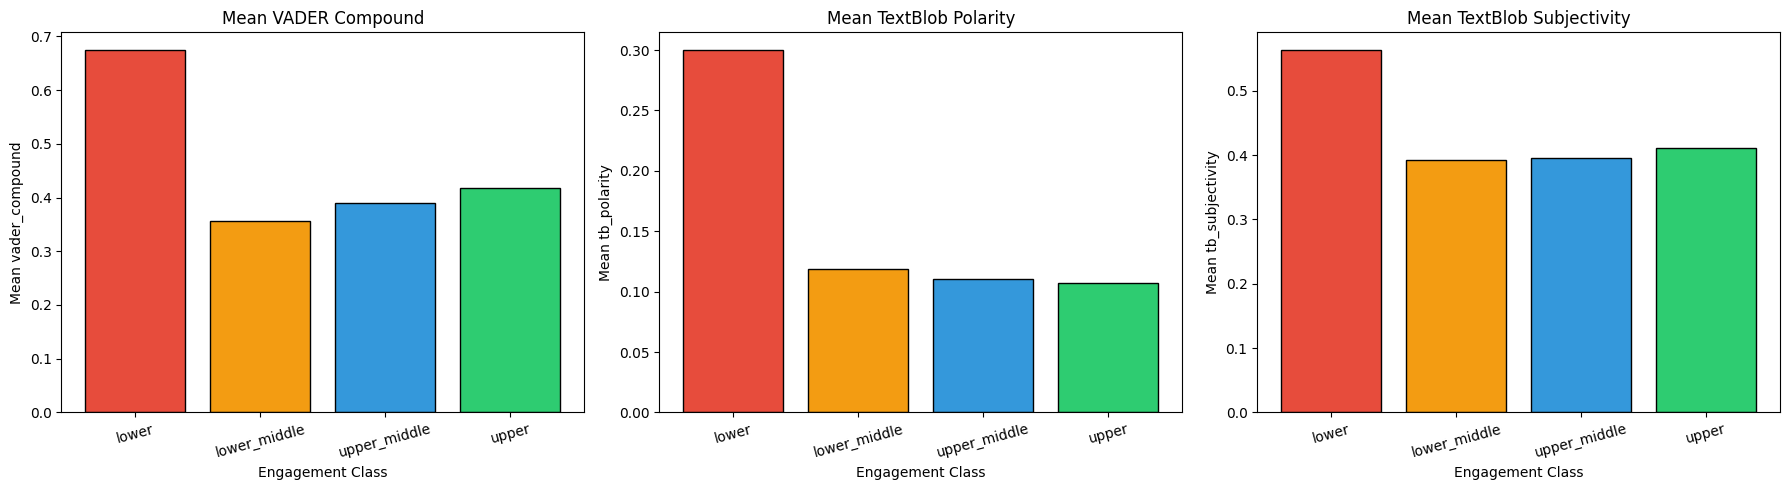

In [24]:
class_order = ["lower", "lower_middle", "upper_middle", "upper"]
colors = ["#e74c3c", "#f39c12", "#3498db", "#2ecc71"]

sent_by_class = (
    sent.groupby("engagement_class", observed=True)[
        ["vader_compound", "tb_polarity", "tb_subjectivity"]
    ]
    .agg(["mean", "median", "std"])
    .reindex(class_order)
    .round(4)
)
display(sent_by_class)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (col, title) in enumerate([
    ("vader_compound", "Mean VADER Compound"),
    ("tb_polarity", "Mean TextBlob Polarity"),
    ("tb_subjectivity", "Mean TextBlob Subjectivity"),
]):
    means = sent.groupby("engagement_class", observed=True)[col].mean().reindex(class_order)
    axes[i].bar(class_order, means, color=colors, edgecolor="black")
    axes[i].set_xlabel("Engagement Class")
    axes[i].set_ylabel(f"Mean {col}")
    axes[i].set_title(title)
    axes[i].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

## Sentiment by topic label

,vader_compound,tb_polarity,tb_subjectivity
topic_label,,,
A,0.3575,0.0979,0.4144
B,0.2914,0.0829,0.4151
C,0.6089,0.2617,0.4961
D,0.3057,0.0936,0.3781
E,0.5320,0.1512,0.4747
F,0.4550,0.1118,0.4153
G,0.2856,0.1249,0.4290
H,0.0497,0.0309,0.1340
I,0.1992,0.0685,0.3534


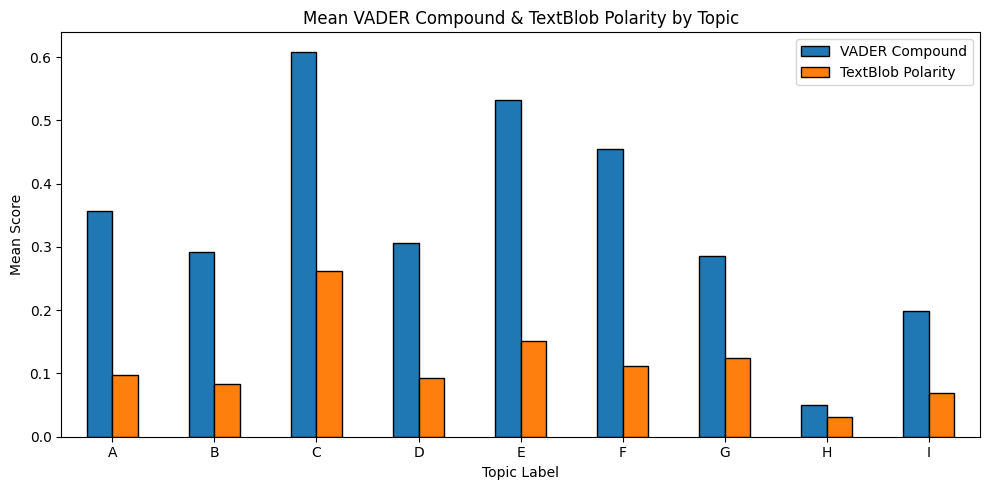

In [25]:
topic_sent = (
    sent.groupby("topic_label", observed=True)[
        ["vader_compound", "tb_polarity", "tb_subjectivity"]
    ]
    .mean()
    .sort_index()
    .round(4)
)
display(topic_sent)

fig, ax = plt.subplots(figsize=(10, 5))
topic_sent[["vader_compound", "tb_polarity"]].plot.bar(ax=ax, edgecolor="black")
ax.set_xlabel("Topic Label")
ax.set_ylabel("Mean Score")
ax.set_title("Mean VADER Compound & TextBlob Polarity by Topic")
ax.legend(["VADER Compound", "TextBlob Polarity"])
ax.tick_params(axis="x", rotation=0)
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.show()

## VADER compound vs. TextBlob polarity correlation

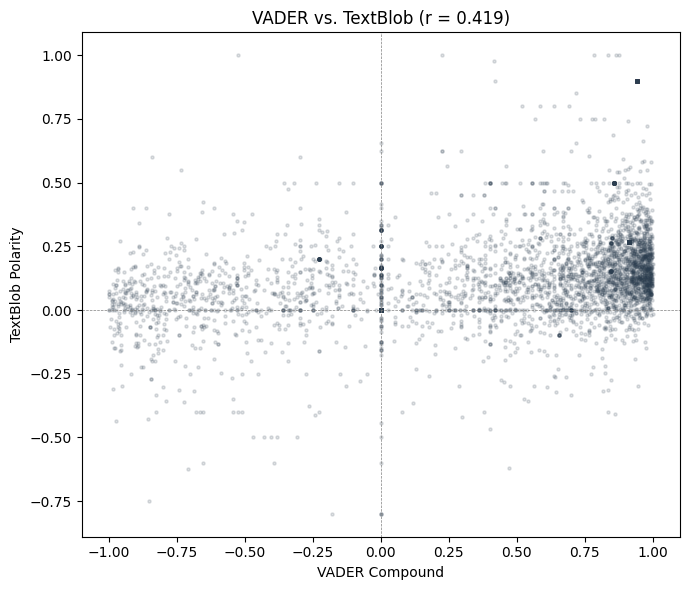

Pearson correlation between VADER compound and TextBlob polarity: 0.4193


In [26]:
corr = sent["vader_compound"].corr(sent["tb_polarity"])

fig, ax = plt.subplots(figsize=(7, 6))
sample = sent.sample(min(5000, len(sent)), random_state=42)
ax.scatter(
    sample["vader_compound"], sample["tb_polarity"],
    alpha=0.15, s=5, color="#2c3e50",
)
ax.set_xlabel("VADER Compound")
ax.set_ylabel("TextBlob Polarity")
ax.set_title(f"VADER vs. TextBlob (r = {corr:.3f})")
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
ax.axvline(0, color="gray", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.show()

print(f"Pearson correlation between VADER compound and TextBlob polarity: {corr:.4f}")